In [1]:
# steps =>

# 1. import data
# 2. data cleaning -> inconsistencies, missing values
# 3. Exploratory data analysis
# 4. Outlier detection and removal
# 5. Data balancing / Resampling
# 6. feature selection/ dimensionality reduction
# 7. cross validation
# 8. Feature scaling
# 9. Algorithms and hyperpara tuning
# 10. model building
# 11. predictions
# 12. deployment


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('grapes_new.csv')
df.head()

,COLOR_INTENSITY,SHAPE,RIPENESS_PER,ALCOHOL_PER,MALIC_ACID_PER,ASH,ALCALINITY_OF_ASH,MAGNESIUM_MEASURE,TOTAL_PHENOLS,FLAVANOIDS,...,HUE,PROLINE,TEMPERATURE,AVG_HUMIDITY,FERT_NITRO_PER,WATER_O2_PER,WATER_PH,FER_P2O5_PER,SOIL_TYPE,CLASS
0,120.53,elliptical,16.73,14.23,1.71,2.43,15.6,127,2.80,3.06,...,1.04,1065,23.34,54.99,31.21,97.67,7.71,52.02,archean,High
1,112.57,elliptical,20.30,13.20,1.78,2.14,11.2,100,2.65,2.76,...,1.05,1050,23.40,51.91,31.28,99.05,7.66,48.18,archean,High
2,120.78,elliptical,20.81,13.16,2.36,2.67,18.6,101,2.80,3.24,...,1.03,1185,22.29,50.69,31.92,97.95,7.66,28.15,archean,High
3,134.17,elliptical,19.47,14.37,1.95,2.50,16.8,113,3.85,3.49,...,0.86,1480,21.28,47.72,31.79,95.46,7.21,55.95,alluvial,High
4,112.19,round,17.57,13.24,2.59,2.87,21.0,118,2.80,2.69,...,1.04,735,23.76,45.09,31.86,94.45,7.80,55.99,archean,High


## Data Cleaning

In [4]:
df.shape

(194, 21)

In [5]:
df.isnull().sum()

COLOR_INTENSITY      0
SHAPE                0
RIPENESS_PER         2
ALCOHOL_PER          3
MALIC_ACID_PER       0
ASH                  0
ALCALINITY_OF_ASH    6
MAGNESIUM_MEASURE    0
TOTAL_PHENOLS        0
FLAVANOIDS           0
PROANTHOCYANINS      0
HUE                  2
PROLINE              0
TEMPERATURE          0
AVG_HUMIDITY         0
FERT_NITRO_PER       0
WATER_O2_PER         4
WATER_PH             0
FER_P2O5_PER         0
SOIL_TYPE            0
CLASS                0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   COLOR_INTENSITY    194 non-null    float64
 1   SHAPE              194 non-null    object 
 2   RIPENESS_PER       192 non-null    float64
 3   ALCOHOL_PER        191 non-null    float64
 4   MALIC_ACID_PER     194 non-null    float64
 5   ASH                194 non-null    float64
 6   ALCALINITY_OF_ASH  188 non-null    float64
 7   MAGNESIUM_MEASURE  194 non-null    int64  
 8   TOTAL_PHENOLS      194 non-null    float64
 9   FLAVANOIDS         194 non-null    float64
 10  PROANTHOCYANINS    194 non-null    float64
 11  HUE                192 non-null    float64
 12  PROLINE            194 non-null    int64  
 13  TEMPERATURE        194 non-null    float64
 14  AVG_HUMIDITY       194 non-null    float64
 15  FERT_NITRO_PER     194 non-null    float64
 16  WATER_O2_PER       190 non

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

COLOR_INTENSITY      float64
SHAPE                 object
RIPENESS_PER         float64
ALCOHOL_PER          float64
MALIC_ACID_PER       float64
ASH                  float64
ALCALINITY_OF_ASH    float64
MAGNESIUM_MEASURE      int64
TOTAL_PHENOLS        float64
FLAVANOIDS           float64
PROANTHOCYANINS      float64
HUE                  float64
PROLINE                int64
TEMPERATURE          float64
AVG_HUMIDITY         float64
FERT_NITRO_PER       float64
WATER_O2_PER         float64
WATER_PH             float64
FER_P2O5_PER         float64
SOIL_TYPE             object
CLASS                 object
dtype: object

In [9]:
df["RIPENESS_PER"] = df["RIPENESS_PER"].fillna(df["RIPENESS_PER"].median())
df["ALCOHOL_PER"] = df["ALCOHOL_PER"].fillna(df["ALCOHOL_PER"].median())
df["ALCALINITY_OF_ASH"] = df["ALCALINITY_OF_ASH"].fillna(df["ALCALINITY_OF_ASH"].median())
df["HUE"] = df["HUE"].fillna(df["HUE"].median())
df["WATER_O2_PER"] = df["WATER_O2_PER"].fillna(df["WATER_O2_PER"].median())

In [10]:
df.isnull().sum()

COLOR_INTENSITY      0
SHAPE                0
RIPENESS_PER         0
ALCOHOL_PER          0
MALIC_ACID_PER       0
ASH                  0
ALCALINITY_OF_ASH    0
MAGNESIUM_MEASURE    0
TOTAL_PHENOLS        0
FLAVANOIDS           0
PROANTHOCYANINS      0
HUE                  0
PROLINE              0
TEMPERATURE          0
AVG_HUMIDITY         0
FERT_NITRO_PER       0
WATER_O2_PER         0
WATER_PH             0
FER_P2O5_PER         0
SOIL_TYPE            0
CLASS                0
dtype: int64

In [11]:
df.columns

Index(['COLOR_INTENSITY', 'SHAPE', 'RIPENESS_PER', 'ALCOHOL_PER',
       'MALIC_ACID_PER', 'ASH', 'ALCALINITY_OF_ASH', 'MAGNESIUM_MEASURE',
       'TOTAL_PHENOLS', 'FLAVANOIDS', 'PROANTHOCYANINS', 'HUE', 'PROLINE',
       'TEMPERATURE', 'AVG_HUMIDITY', 'FERT_NITRO_PER', 'WATER_O2_PER',
       'WATER_PH', 'FER_P2O5_PER', 'SOIL_TYPE', 'CLASS'],
      dtype='object')

In [12]:
df.columns = df.columns.str.strip()

In [13]:
# Separate input and output
x = df.drop('CLASS', axis = 1)
y = df['CLASS']

## EDA

In [14]:
df.describe()

,COLOR_INTENSITY,RIPENESS_PER,ALCOHOL_PER,MALIC_ACID_PER,ASH,ALCALINITY_OF_ASH,MAGNESIUM_MEASURE,TOTAL_PHENOLS,FLAVANOIDS,PROANTHOCYANINS,HUE,PROLINE,TEMPERATURE,AVG_HUMIDITY,FERT_NITRO_PER,WATER_O2_PER,WATER_PH,FER_P2O5_PER
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000
mean,116.882113,21.515773,13.024639,2.335103,2.365361,19.485567,99.680412,2.296649,2.016856,1.577216,0.955938,754.164948,26.418247,50.976082,30.562216,90.177629,7.680979,42.195155
std,14.333204,2.374368,0.803311,1.118041,0.268158,3.381157,14.252749,0.634317,1.001351,0.565445,0.227040,316.093797,3.042364,3.367880,1.126867,5.308245,0.509935,10.398205
min,93.000000,16.170000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.410000,0.480000,278.000000,21.020000,44.230000,27.670000,80.360000,6.510000,20.000000
25%,105.470000,20.372500,12.370000,1.610000,2.210000,17.200000,88.000000,1.725000,1.092500,1.225000,0.790000,504.000000,24.222500,48.360000,29.932500,85.862500,7.252500,33.742500
50%,114.910000,21.820000,13.050000,1.865000,2.360000,19.500000,97.500000,2.355000,2.135000,1.545000,0.975000,675.000000,26.195000,51.145000,30.710000,90.160000,7.670000,44.820000
75%,124.060000,23.317500,13.677500,3.082500,2.547500,21.375000,107.000000,2.800000,2.875000,1.950000,1.107500,988.750000,28.737500,53.722500,31.382500,94.427500,8.127500,50.542500
max,167.000000,25.200000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,3.580000,1.710000,1680.000000,32.340000,57.950000,34.160000,99.770000,8.500000,60.870000


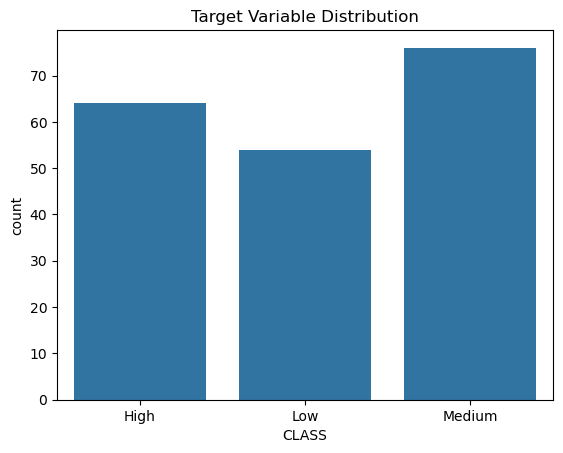

In [15]:
sns.countplot(x="CLASS", data=df)
plt.title("Target Variable Distribution")
plt.show()

In [16]:
one = df.iloc[:, :4]
one['CLASS'] = y
two = df.iloc[:, 4:8]
two['CLASS'] = y
three = df.iloc[:, 8:12]
three['CLASS'] = y
four = df.iloc[:, 12:16]
four['CLASS'] = y
five = df.iloc[:, 16:20]
five['CLASS'] = y

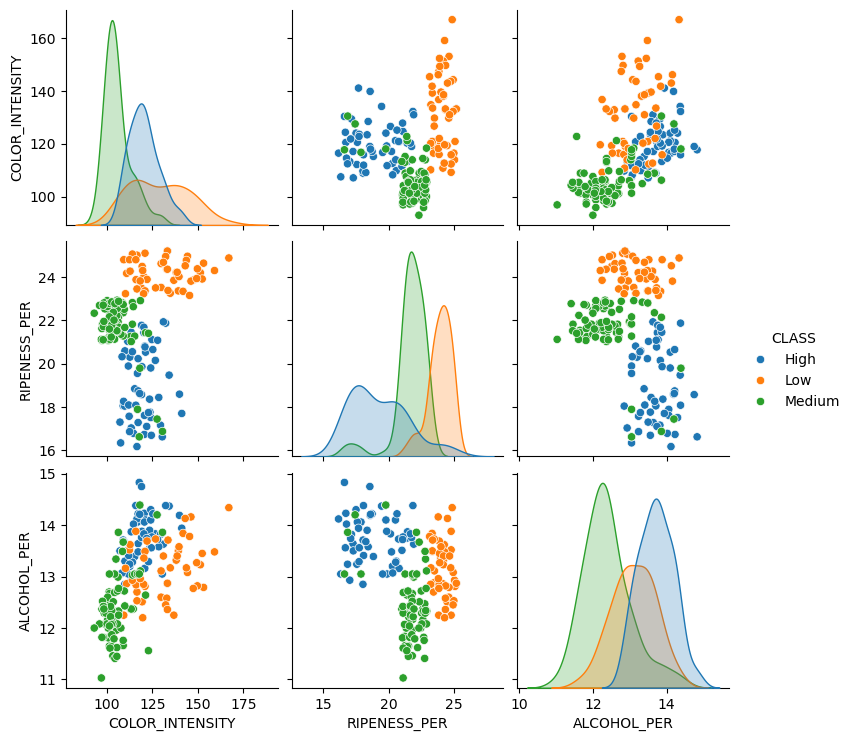

In [17]:
sns.pairplot(one, hue = 'CLASS');

## Outlier Detection and Removal

In [18]:
x.dtypes

COLOR_INTENSITY      float64
SHAPE                 object
RIPENESS_PER         float64
ALCOHOL_PER          float64
MALIC_ACID_PER       float64
ASH                  float64
ALCALINITY_OF_ASH    float64
MAGNESIUM_MEASURE      int64
TOTAL_PHENOLS        float64
FLAVANOIDS           float64
PROANTHOCYANINS      float64
HUE                  float64
PROLINE                int64
TEMPERATURE          float64
AVG_HUMIDITY         float64
FERT_NITRO_PER       float64
WATER_O2_PER         float64
WATER_PH             float64
FER_P2O5_PER         float64
SOIL_TYPE             object
dtype: object

In [19]:
x = pd.get_dummies(x, drop_first = True)

In [20]:
col_order_ohe = x.columns.tolist()

In [21]:
col_order_ohe

['COLOR_INTENSITY',
 'RIPENESS_PER',
 'ALCOHOL_PER',
 'MALIC_ACID_PER',
 'ASH',
 'ALCALINITY_OF_ASH',
 'MAGNESIUM_MEASURE',
 'TOTAL_PHENOLS',
 'FLAVANOIDS',
 'PROANTHOCYANINS',
 'HUE',
 'PROLINE',
 'TEMPERATURE',
 'AVG_HUMIDITY',
 'FERT_NITRO_PER',
 'WATER_O2_PER',
 'WATER_PH',
 'FER_P2O5_PER',
 'SHAPE_round',
 'SOIL_TYPE_archean']

In [22]:
# isolation forest for outlier removal

In [23]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination = 0.05, random_state = 0)

In [24]:
clean = iso.fit_predict(x)

In [25]:
clean

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1])

In [26]:
x = x[clean == 1]

In [27]:
y = y[clean == 1]

In [28]:
x.shape

(184, 20)

## Sampling (over sampling)

In [29]:
y.shape

(184,)

In [30]:
y.value_counts()

CLASS
Medium    71
High      64
Low       49
Name: count, dtype: int64

In [31]:
from imblearn.over_sampling import SMOTE

In [32]:
smote = SMOTE(k_neighbors = 5)

In [33]:
x_res, y_res = smote.fit_resample(x, y)

In [34]:
y_res.value_counts()

CLASS
High      71
Low       71
Medium    71
Name: count, dtype: int64

## Feature Selection

In [35]:
from sklearn.feature_selection import SelectKBest, chi2

In [36]:
skf = SelectKBest(k = 5, score_func = chi2)

In [37]:
x_new = skf.fit_transform(x_res, y_res)

In [38]:
x_new.shape

(213, 5)

In [39]:
skf.get_support()

array([ True, False, False, False, False, False, False, False,  True,
       False, False,  True,  True, False, False, False, False,  True,
       False, False])

In [40]:
skf.get_feature_names_out()

array(['COLOR_INTENSITY', 'FLAVANOIDS', 'PROLINE', 'TEMPERATURE',
       'FER_P2O5_PER'], dtype=object)

In [41]:
x = x_res.loc[:, skf.get_support()]

In [42]:
x;

In [43]:
x.shape, y_res.shape

((213, 5), (213,))

In [44]:
x.describe()

,COLOR_INTENSITY,FLAVANOIDS,PROLINE,TEMPERATURE,FER_P2O5_PER
count,213.000000,213.000000,213.000000,213.000000,213.000000
mean,117.651310,1.907694,760.985915,26.611197,41.741410
std,13.253253,1.010940,308.036164,3.111985,10.124361
min,93.000000,0.470000,278.000000,21.020000,20.000000
25%,106.390000,0.830000,520.000000,24.230000,33.330000
50%,117.120000,2.000000,680.000000,26.350000,44.030000
75%,124.380000,2.790000,990.000000,29.303991,49.030000
max,153.110000,3.930000,1680.000000,32.340000,60.870000


## Cross Validation

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
x_train, x_test, y_train, y_test = train_test_split(x, y_res, random_state = 0, test_size = 0.20, stratify = y_res)

In [47]:
x_train.shape, y_train.shape

((170, 5), (170,))

## Feature Scaling

In [48]:
from sklearn.preprocessing import MinMaxScaler
sca = MinMaxScaler()

In [49]:
x_train_scaled = sca.fit_transform(x_train)
x_test_scaled = sca.transform(x_test)

In [50]:
x_train_scaled.shape, y_train.shape

((170, 5), (170,))

## Build the Model

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [52]:
params = {'random_state' : [0, 42],
          'criterion' : ['gini', 'entropy'],
          'max_features' : ['sqrt', 'log2'],
          'n_estimators' : [20, 30, 100]}

In [53]:
grid = GridSearchCV(estimator = RandomForestClassifier(),
                    param_grid = params,
                    scoring = 'accuracy',
                    cv = 5)

In [54]:
grid.fit(x_train_scaled, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_features': ['sqrt', 'log2'], 'n_estimators': [20, 30, ...], 'random_state': [0, 42]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [55]:
y_pred = grid.predict(x_test_scaled)

In [56]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

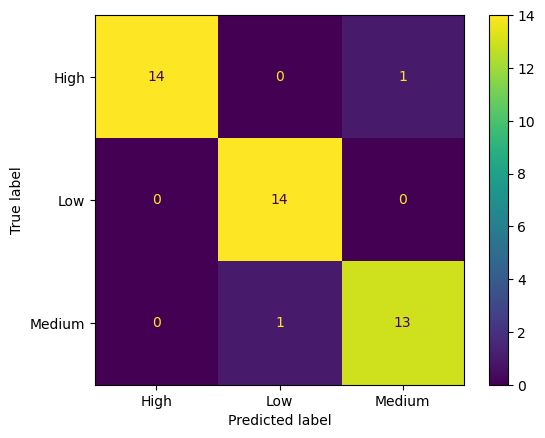

In [57]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [58]:
accuracy_score(y_test, y_pred)

0.9534883720930233

In [59]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      0.93      0.97        15
         Low       0.93      1.00      0.97        14
      Medium       0.93      0.93      0.93        14

    accuracy                           0.95        43
   macro avg       0.95      0.95      0.95        43
weighted avg       0.96      0.95      0.95        43



In [60]:
## Serialize

In [61]:
import joblib

In [62]:
# save the model
joblib.dump(grid, 'rf_classifier.pkl')

['rf_classifier.pkl']

In [63]:
joblib.dump(sca, 'rf_scaler.pkl')

['rf_scaler.pkl']

In [64]:
x.columns

Index(['COLOR_INTENSITY', 'FLAVANOIDS', 'PROLINE', 'TEMPERATURE',
       'FER_P2O5_PER'],
      dtype='object')